In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from rdkit import Chem
from molfeat.calc import FPCalculator
from molfeat.trans import MoleculeTransformer

# GSLF data
chem_space = pd.read_csv('gslf_dataset.csv', index_col=0)
# Toy dataset
dataset = ['4-Methylanisole', 'm-Cresol', 'Vanillylacetone', '2,6-Dimethoxyphenol', 'Carvacrol', 'Methyl eugenol', 'Guaiacol ', '2-Isopropylphenol', '2-methoxy-4-vinylphenol']

Useful functions to convert Odorant Names to CIDs and then into SMILES

In [5]:
import pubchempy as pcp
from pyrfume.odorants import get_cids
# import logging
# logging.basicConfig(level=logging.DEBUG)

def get_cids_from_names(odor_names):
    """"
    Unfortunately, one can't batch request names so one has to run them sequentially.
    If a name fails to parse, it will return a CID of zero (0).
    """
    cids = get_cids(odor_names, wait=0.2)
    cids = pd.Series(cids, name = 'cid')

    failed = cids.where(cids == 0).dropna().index

    if len(failed) == 0:
        return cids
    else:
        print('The following odors failed to parse, please retry')
        print(failed)

        return cids

def get_smiles_from_cids(cids: list, datatype = "cid"):
    """
    PCP handles this in batches, however run the dataset in batches of less than ~200 or so
    as to not trigger any timeouts from the Pubchem API.
        Returns ISOMERIC SMILES
    """
    # Make sure there are no 0 | other invalid values in the cids
    df = pcp.get_properties(['SMILES'], cids, 'cid', as_dataframe=True)
    return df

In [6]:
cids = get_cids_from_names(dataset)
df = get_smiles_from_cids(list(cids.values))

  0%|          | 0/9 [00:00<?, ?it/s]

[17:27:52] ERROR: 

[17:27:53] ERROR: 

[17:27:54] ERROR: 

[17:27:54] ERROR: 

[17:27:55] ERROR: 

[17:27:55] ERROR: 

[17:27:56] ERROR: 

[17:27:57] ERROR: 

[17:27:57] ERROR: 



Calculate Chemical Fingerprints

In [7]:
# Choose the fingerprints
calc = FPCalculator('maccs') # Other fingerprints: FPCalculator("ecfp", {'radius': 2, 'nBits': 1042}) # morgan fingerprints

# Create the transformer
mol_transf = MoleculeTransformer(calc, n_jobs=-1) # cal

# Create a 'mol' column to calculate fingerprints
chem_space['mol'] = [Chem.MolFromSmiles(s) for s in chem_space.smiles]
space_fps = pd.DataFrame(mol_transf(chem_space.mol), index = chem_space.index)

df['mol'] = [Chem.MolFromSmiles(s) for s in df.SMILES]
df_fps = pd.DataFrame(mol_transf(df.mol), index = df.index)


[17:27:59] WARNING: not removing hydrogen atom without neighbors
[17:27:59] WARNING: not removing hydrogen atom without neighbors


Calculating PC space

In [ ]:
pca = PCA(n_components=0.9)

# If dataset contains odors not in chemical space, append them to fit PCA
mask = df_fps.index.isin(space_fps.index)
combined_data = pd.concat([df_fps.loc[~mask], space_fps], axis=0)
pca.fit(combined_data.values)

pc_space = pd.DataFrame(pca.transform(space_fps))
pc_dataset = pd.DataFrame(pca.transform(df_fps))

# pca_explaine

Matplotlib Visualisation

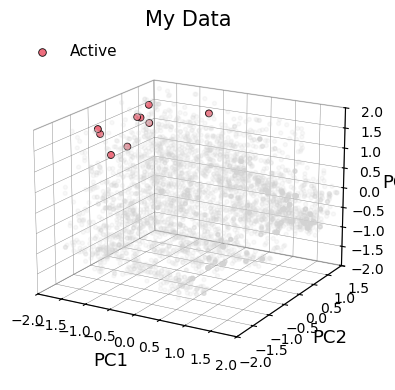

In [23]:
def plot_pc_space(pc_coords, pc_space_data, zoom, title):
    fig = plt.figure(figsize=(5, 4))
    ax = fig.add_subplot(111, projection='3d')

    # optional: zoom-in
    if zoom:
        mask = (
            pc_space_data.iloc[:,0].between(-2, 2) &
            pc_space_data.iloc[:,1].between(-2, 1.5) &
            pc_space_data.iloc[:,2].between(-2, 2))
        pc_space_filtered = pc_space_data[mask]
    else:
        pc_space_filtered = pc_space_data
    
    ax.scatter(pc_space_filtered.iloc[:,0], pc_space_filtered.iloc[:,1], pc_space_filtered.iloc[:,2],
               c='lightgray', s=8, alpha=0.15, depthshade=True)

    ax.scatter(pc_coords.iloc[:,0], pc_coords.iloc[:,1], pc_coords.iloc[:,2],
               s=25, alpha=0.95, c='#EE6677',
               edgecolors='black', linewidths=0.6,
               depthshade=True, label='Active')

    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor('white')
        axis.pane.set_edgecolor('lightgray')
        axis.pane.set_alpha(1.0)
        axis._axinfo['grid'].update(color='gray', linewidth=0.3, alpha=0.25)

    ax.set_xlabel('PC1', size=13)
    ax.set_ylabel('PC2', size=13)
    ax.set_zlabel('PC3', size=13)
    ax.set_title(title, size=15, pad=0)

    if zoom:
        ax.set_xlim(-2, 2); ax.set_ylim(-2, 1.5); ax.set_zlim(-2, 2)

    ax.tick_params(length=0)
    ax.view_init(elev=18, azim=-60)
    ax.legend(loc='upper left', frameon=False, fontsize=11, markerscale=1.1)
    fig.tight_layout()
    
    return fig

# Now call it with pc_space as an argument
fig = plot_pc_space(pc_dataset, pc_space, zoom = True, title='My Data')

Interactive Plot

In [ ]:
import plotly.graph_objects as go
def plotly_viz(pc_coords, pcspace, title='', z_floor=-2):

    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=pcspace.iloc[:, 0], y=pcspace.iloc[:, 1], z=pcspace.iloc[:, 2],
        mode='markers',
        marker=dict(size=2, color='lightgray', opacity=0.22),
        showlegend=False, hoverinfo='skip'))
    
    fig.add_trace(go.Scatter3d(
        x=pc_coords.iloc[:, 0], y=pc_coords.iloc[:, 1], z=pc_coords.iloc[:, 2],
        mode='markers',
        marker=dict(size=8, color='#EE6677', opacity=0.95,
                    line=dict(width=2, color='black')),
        showlegend=False,
        text=pc_coords.index, hovertemplate='%{text}<extra></extra>'))

    axis_style = dict(
        backgroundcolor='white',
        showbackground=True,
        showticklabels=False,
        showgrid=True,
        ticks='',
        zeroline=False,
        showline=True,
        linecolor='black',
        linewidth=2,
    )
    scene_dict = dict(
            xaxis=dict(title = "PC1",   **axis_style),
            yaxis=dict(title = "PC2", **axis_style),
            zaxis=dict(title = "PC3", **axis_style),
            aspectmode='cube',
            )

    fig.update_layout(
        title=title,
        width=700, height=600,
        showlegend=False,
        scene= scene_dict,
        margin=dict(l=0, r=0, t=40, b=0),
        template='simple_white')
    return fig


fig = plotly_viz(pc_dataset, pc_space, title='Olfr649')
fig.show()